In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load dataset
df = pd.read_csv('../data/Reviews.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst look:")
df.head()

Dataset shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

First look:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


=== DATASET INFO ===
Total reviews: 568,454

Missing values:
Score       0
Text        0
Summary    27
dtype: int64

=== SCORE DISTRIBUTION ===
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

Average score: 4.18


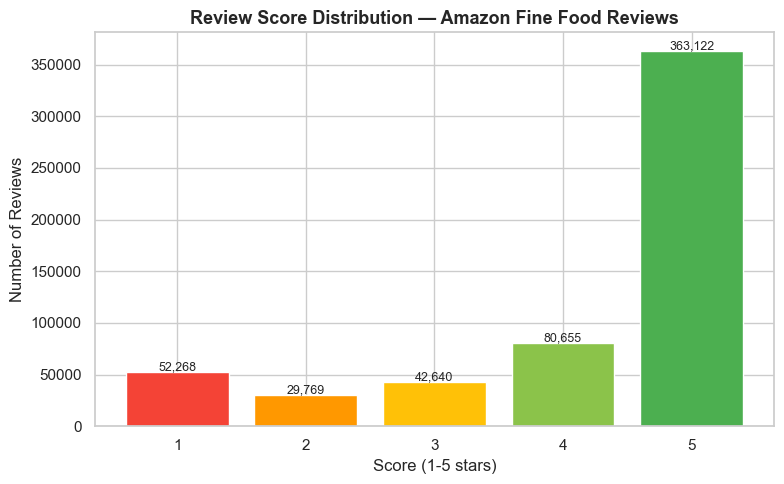

In [4]:
# Check basic info and missing values
print("=== DATASET INFO ===")
print(f"Total reviews: {len(df):,}")
print(f"\nMissing values:")
print(df[['Score', 'Text', 'Summary']].isnull().sum())

# Score distribution
print(f"\n=== SCORE DISTRIBUTION ===")
print(df['Score'].value_counts().sort_index())
print(f"\nAverage score: {df['Score'].mean():.2f}")

# Visualize score distribution
plt.figure(figsize=(8, 5))
score_counts = df['Score'].value_counts().sort_index()
colors = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
plt.bar(score_counts.index, score_counts.values, color=colors)
plt.title('Review Score Distribution — Amazon Fine Food Reviews', 
          fontsize=13, fontweight='bold')
plt.xlabel('Score (1-5 stars)')
plt.ylabel('Number of Reviews')
for i, (score, count) in enumerate(zip(score_counts.index, score_counts.values)):
    plt.text(score, count + 2000, f'{count:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../img/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

=== SENTIMENT DISTRIBUTION ===
sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64

Sentiment %:
sentiment
Positive    78.1
Negative    14.4
Neutral      7.5
Name: proportion, dtype: float64


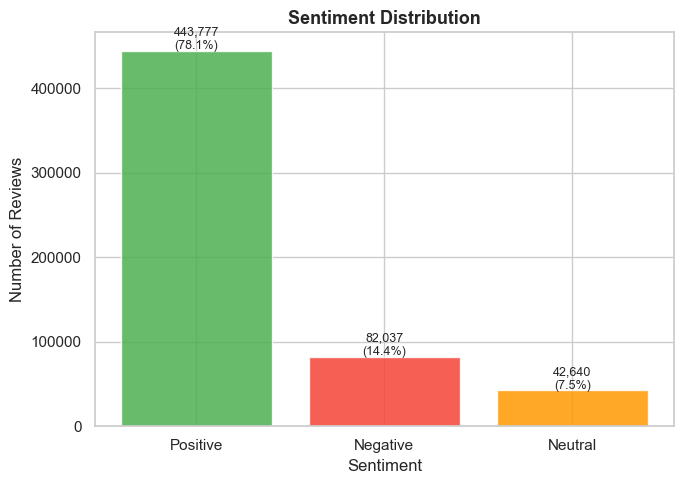

In [5]:
# Create sentiment labels from scores
# 1-2 stars = Negative, 3 stars = Neutral, 4-5 stars = Positive
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['Score'].apply(get_sentiment)

# Check distribution
print("=== SENTIMENT DISTRIBUTION ===")
print(df['sentiment'].value_counts())
print(f"\nSentiment %:")
print(df['sentiment'].value_counts(normalize=True).mul(100).round(1))

# Visualize
plt.figure(figsize=(7, 5))
sentiment_counts = df['sentiment'].value_counts()
colors = ['#4CAF50', '#F44336', '#FF9800']
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.85)
plt.title('Sentiment Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
for i, (sent, count) in enumerate(zip(sentiment_counts.index, sentiment_counts.values)):
    plt.text(i, count + 2000, f'{count:,}\n({count/len(df)*100:.1f}%)', 
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../img/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download('stopwords')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("Cleaning text — this may take a few minutes...")

# Work with a sample for speed - 100K reviews is more than enough
df_sample = df.sample(n=100000, random_state=42).copy()
df_sample['clean_text'] = df_sample['Text'].apply(clean_text)

print(f"Done. Sample size: {len(df_sample):,}")
print(f"\nOriginal text example:")
print(df_sample['Text'].iloc[0][:200])
print(f"\nCleaned text example:")
print(df_sample['clean_text'].iloc[0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Andres\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Andres\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Cleaning text — this may take a few minutes...
Done. Sample size: 100,000

Original text example:
Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  S

Cleaned text example:
tried couple brands glutenfree sandwich cookies best bunch theyre crunchy true texture real cookies arent glutenfree might think filling makes bit sweet means ive satisfied sweet tooth sooner chocolat


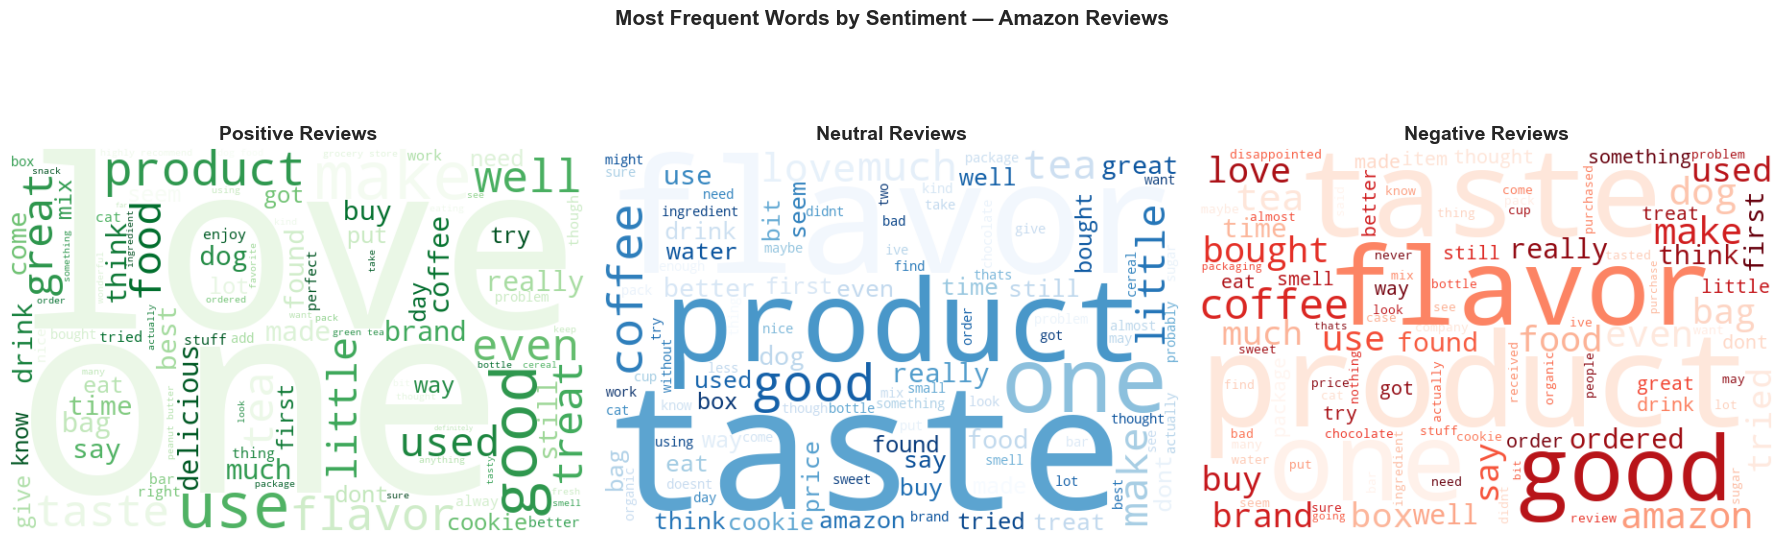

WordClouds saved.


In [8]:
# Generate WordClouds by sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = ['Positive', 'Neutral', 'Negative']
colors_map = ['Greens', 'Blues', 'Reds']
titles = ['Positive Reviews', 'Neutral Reviews', 'Negative Reviews']

for ax, sentiment, colormap, title in zip(axes, sentiments, colors_map, titles):
    # Get text for this sentiment
    text = ' '.join(df_sample[df_sample['sentiment'] == sentiment]['clean_text'])
    
    # Generate wordcloud
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        random_state=42
    ).generate(text)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Frequent Words by Sentiment — Amazon Reviews',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../img/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

print("WordClouds saved.")

Calculating TextBlob sentiment — please wait...

=== TEXTBLOB ACCURACY vs ACTUAL SENTIMENT ===
              precision    recall  f1-score   support

    Negative       0.59      0.22      0.32     14315
     Neutral       0.12      0.31      0.17      7422
    Positive       0.86      0.83      0.85     78263

    accuracy                           0.71    100000
   macro avg       0.52      0.45      0.45    100000
weighted avg       0.77      0.71      0.72    100000



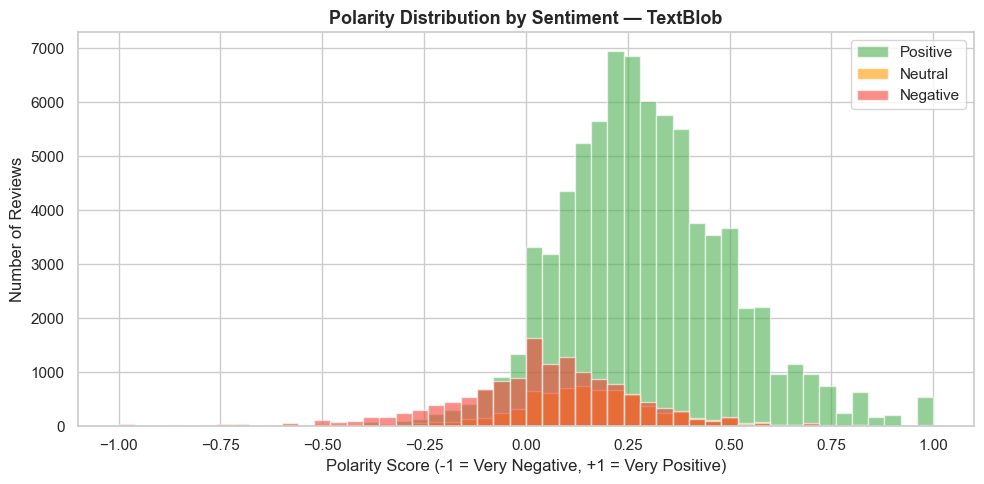

In [10]:
from textblob import TextBlob

# Calculate sentiment polarity with TextBlob
print("Calculating TextBlob sentiment — please wait...")

df_sample['polarity'] = df_sample['clean_text'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# Create TextBlob sentiment label
def polarity_to_sentiment(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['textblob_sentiment'] = df_sample['polarity'].apply(polarity_to_sentiment)

# Compare TextBlob vs actual score-based sentiment
print("\n=== TEXTBLOB ACCURACY vs ACTUAL SENTIMENT ===")
from sklearn.metrics import classification_report
print(classification_report(
    df_sample['sentiment'],
    df_sample['textblob_sentiment'],
    target_names=['Negative', 'Neutral', 'Positive']
))

# Polarity distribution by sentiment
plt.figure(figsize=(10, 5))
for sentiment, color in zip(['Positive', 'Neutral', 'Negative'], 
                              ['#4CAF50', '#FF9800', '#F44336']):
    subset = df_sample[df_sample['sentiment'] == sentiment]['polarity']
    plt.hist(subset, bins=50, alpha=0.6, color=color, label=sentiment)

plt.title('Polarity Distribution by Sentiment — TextBlob', 
          fontsize=13, fontweight='bold')
plt.xlabel('Polarity Score (-1 = Very Negative, +1 = Very Positive)')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('../img/polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import time

# Prepare data
X = df_sample['clean_text']
y = df_sample['sentiment']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,}")
print(f"Test set: {len(X_test):,}")

# TF-IDF vectorization
print("\nVectorizing text with TF-IDF...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

# Train Logistic Regression with class balancing
print("\nTraining Logistic Regression...")
start = time.time()
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)
lr_model.fit(X_train_tfidf, y_train)
elapsed = time.time() - start

print(f"Training completed in {elapsed:.1f} seconds")

# Evaluate
y_pred = lr_model.predict(X_test_tfidf)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(classification_report(y_test, y_pred, 
      target_names=['Negative', 'Neutral', 'Positive']))

Training set: 80,000
Test set: 20,000

Vectorizing text with TF-IDF...
Feature matrix shape: (80000, 10000)

Training Logistic Regression...
Training completed in 2.8 seconds

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

    Negative       0.61      0.73      0.66      2863
     Neutral       0.26      0.54      0.35      1484
    Positive       0.96      0.83      0.89     15653

    accuracy                           0.79     20000
   macro avg       0.61      0.70      0.63     20000
weighted avg       0.86      0.79      0.81     20000



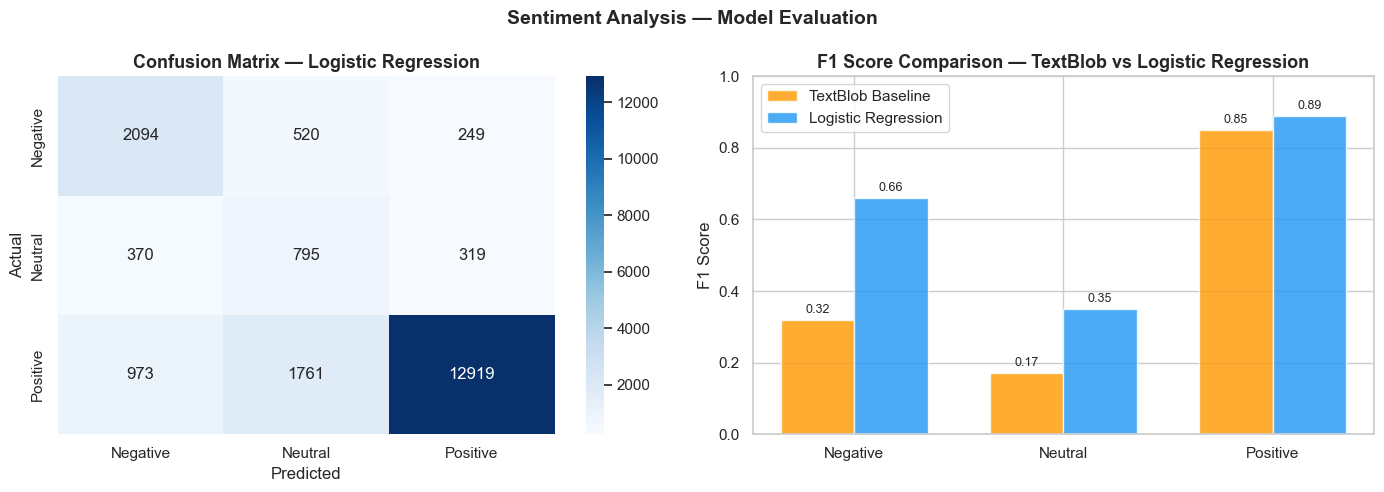

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Model comparison — F1 scores
categories = ['Negative', 'Neutral', 'Positive']
textblob_f1 = [0.32, 0.17, 0.85]
lr_f1 = [0.66, 0.35, 0.89]

x = np.arange(len(categories))
width = 0.35

axes[1].bar(x - width/2, textblob_f1, width, 
            label='TextBlob Baseline', color='#FF9800', alpha=0.8)
axes[1].bar(x + width/2, lr_f1, width,
            label='Logistic Regression', color='#2196F3', alpha=0.8)
axes[1].set_title('F1 Score Comparison — TextBlob vs Logistic Regression',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1)
axes[1].legend()

for i, (tb, lr) in enumerate(zip(textblob_f1, lr_f1)):
    axes[1].text(i - width/2, tb + 0.02, f'{tb}', ha='center', fontsize=9)
    axes[1].text(i + width/2, lr + 0.02, f'{lr}', ha='center', fontsize=9)

plt.suptitle('Sentiment Analysis — Model Evaluation', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

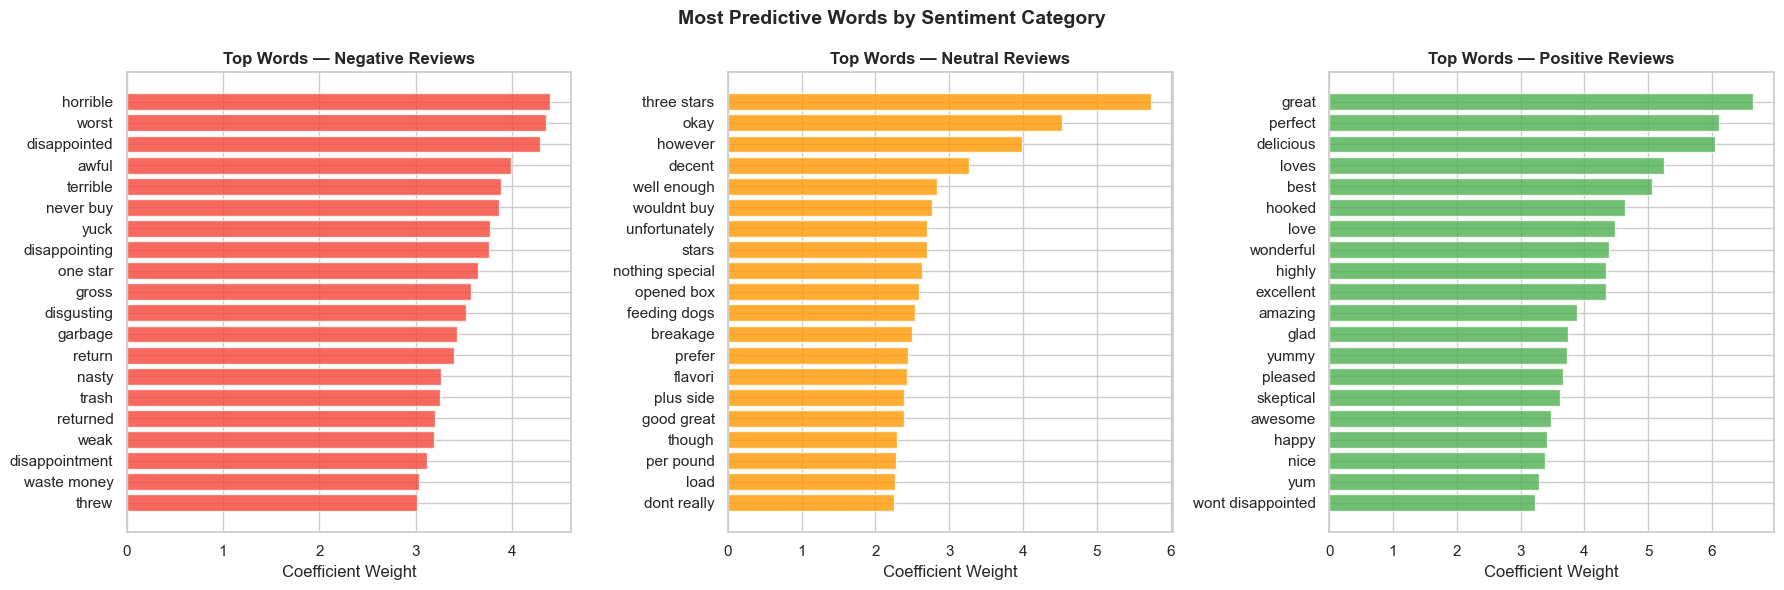

In [13]:
# Extract top predictive words per sentiment
feature_names = tfidf.get_feature_names_out()
classes = lr_model.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#F44336', '#FF9800', '#4CAF50']

for ax, sentiment, color in zip(axes, classes, colors):
    idx = list(classes).index(sentiment)
    coefs = lr_model.coef_[idx]
    top_indices = coefs.argsort()[-20:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [coefs[i] for i in top_indices]
    
    ax.barh(top_words[::-1], top_scores[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top Words — {sentiment} Reviews', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient Weight')

plt.suptitle('Most Predictive Words by Sentiment Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

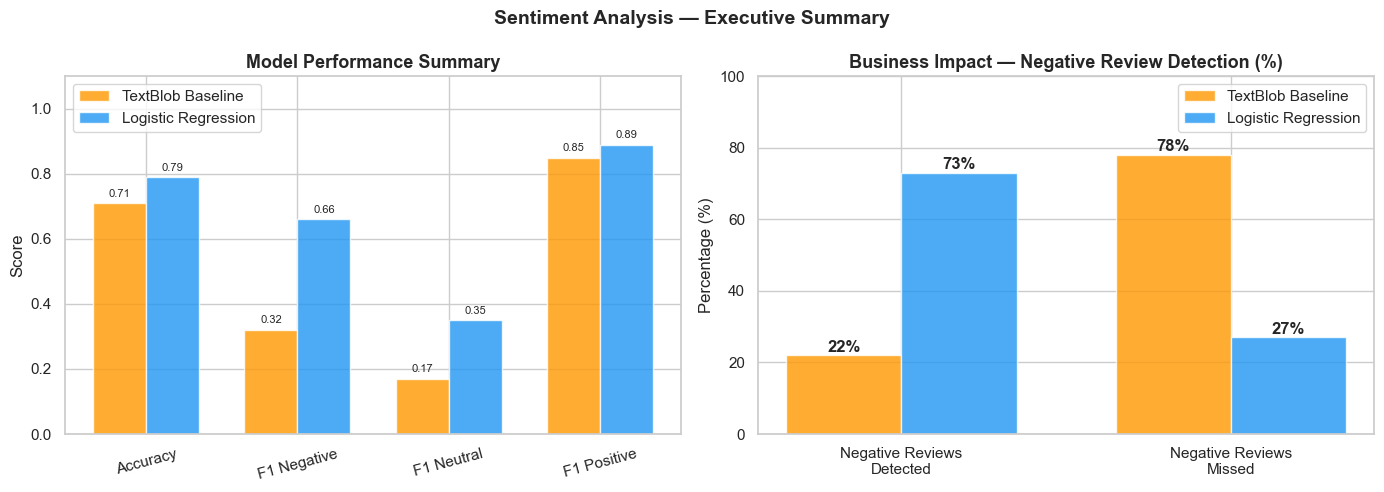

=== PROJECT COMPLETE ===

Dataset: 568,454 Amazon reviews
Sample analyzed: 100,000 reviews
Model: TF-IDF + Logistic Regression
Accuracy: 79%
Negative F1: 0.66 (vs 0.32 TextBlob baseline)

Key business insight:
Model detects 73% of negative reviews vs 22% with TextBlob
Top negative drivers: 'horrible', 'worst', 'disappointed', 'waste money', 'return'


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Model performance summary
metrics = ['Accuracy', 'F1 Negative', 'F1 Neutral', 'F1 Positive']
textblob_scores = [0.71, 0.32, 0.17, 0.85]
lr_scores = [0.79, 0.66, 0.35, 0.89]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, textblob_scores, width,
                     label='TextBlob Baseline', color='#FF9800', alpha=0.8)
bars2 = axes[0].bar(x + width/2, lr_scores, width,
                     label='Logistic Regression', color='#2196F3', alpha=0.8)
axes[0].set_title('Model Performance Summary', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

for bar, val in zip(bars1, textblob_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val}', ha='center', fontsize=8)
for bar, val in zip(bars2, lr_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val}', ha='center', fontsize=8)

# 2. Business impact
categories = ['Negative Reviews\nDetected', 'Negative Reviews\nMissed']
textblob_vals = [22, 78]
lr_vals = [73, 27]

x = np.arange(len(categories))
bars3 = axes[1].bar(x - width/2, textblob_vals, width,
                     label='TextBlob Baseline', color='#FF9800', alpha=0.8)
bars4 = axes[1].bar(x + width/2, lr_vals, width,
                     label='Logistic Regression', color='#2196F3', alpha=0.8)
axes[1].set_title('Business Impact — Negative Review Detection (%)',
                   fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()

for bar, val in zip(bars3, textblob_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontweight='bold')
for bar, val in zip(bars4, lr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}%', ha='center', fontweight='bold')

plt.suptitle('Sentiment Analysis — Executive Summary', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== PROJECT COMPLETE ===")
print(f"\nDataset: 568,454 Amazon reviews")
print(f"Sample analyzed: 100,000 reviews")
print(f"Model: TF-IDF + Logistic Regression")
print(f"Accuracy: 79%")
print(f"Negative F1: 0.66 (vs 0.32 TextBlob baseline)")
print(f"\nKey business insight:")
print(f"Model detects 73% of negative reviews vs 22% with TextBlob")
print(f"Top negative drivers: 'horrible', 'worst', 'disappointed', 'waste money', 'return'")